# Correlating Variables in Models

Temporal Correlations in CMIP6 Models; Climate and Big Data Week 5 

Last Update February 15th, 2026 by Lillian Miller

## Import packages 

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.signal import detrend
import pandas as pd

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

import scipy.stats as st 
from scipy.stats import linregress #this is the new package we will be using to do our correlations 

#ignore warnings from Python (you will see some minor warnings throughout the code if you delete these lines) 
#can be dangerous to always ignore warnings, but here they just impede the readability of the outputs 
import warnings
warnings.filterwarnings('ignore')

## Import Data 

This section will show you an easier way to search NCAR datastores and pull the data you need! We will make use of a function called "get_path" which takes in (in this order) 
1) the **name of the model** you want data for ;
2) the **variable** you want data for
3) the **data type** - what type of data this variable falls under, in this case we want ocean monthly or Omon
4) the **experiment id** (In this case we will use **historical** data, but you may want to use different in the future - more here later)
5) the **activity id**, which is just an NCAR identifier saying we want data from the CMIP collecton, this will never change

This function returns a path to the data file (or files) that correspond to your query. If you are pulling data for the first time, or are getting odd results it is always a good idea to print out this path and make sure that it is a) returning an actual path, and b) is what you intended. If you ever are unsure if it is returing the correct thing or want to check on the availability of data, you can search through NCAR's data directories using the instructions in the NCAR tour video. 

*Technical Notes*: this will always return the regridded grid when available, natural grid only when regridded is not available

Don't worry about understanding everything going on in this function - its just important you know how to use it! Jump to below! 

### Data import function

In [2]:
def get_path(model, variable, data_type, experiment_id, activity_id):
    '''
    function to pull paths for model data from CMIP6
    If this ever doesn't work for you, let me know- I (lillian) am still developing it and may need to add more exceptions! 
    '''
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path


### Using Data import Function

In [3]:
model = "CESM2" # specify the name of the model you are using 

In [4]:
# run the get_path function to get the directions to the data you want 
### nitrate data###
path_no3 = get_path(model,"no3", "Omon", "historical","CMIP") # pull data for the nitrate (no3) variable

#### East -West Wind Stress" 
path_tauuo = get_path(model,"tauuo", "Omon", "historical","CMIP") # pull data for the sea surface temperature (tauuo) variable

In [5]:
#Print out your paths to make sure they make some sense 
print(path_no3)
print(path_tauuo)

['/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/no3/gr/v20190308/no3_Omon_CESM2_historical_r1i1p1f1_gr_185001-201412.nc']
['/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/tauuo/gr/v20190308/tauuo_Omon_CESM2_historical_r1i1p1f1_gr_185001-201412.nc']


**Open & Print out Your Data**

In [6]:
data_no3 = xr.open_mfdataset(path_no3, chunks = None) # open no3 data into a xarray dataset (opens all files as one dataset)
data_tauuo = xr.open_mfdataset(path_tauuo, chunks = None) # open tos data into a xarray dataset (opens all files as one dataset)

In [8]:
## print your first  datset 
print(data_no3.lon.values)

[  0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5  11.5
  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5  23.5
  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5  35.5
  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5  47.5
  48.5  49.5  50.5  51.5  52.5  53.5  54.5  55.5  56.5  57.5  58.5  59.5
  60.5  61.5  62.5  63.5  64.5  65.5  66.5  67.5  68.5  69.5  70.5  71.5
  72.5  73.5  74.5  75.5  76.5  77.5  78.5  79.5  80.5  81.5  82.5  83.5
  84.5  85.5  86.5  87.5  88.5  89.5  90.5  91.5  92.5  93.5  94.5  95.5
  96.5  97.5  98.5  99.5 100.5 101.5 102.5 103.5 104.5 105.5 106.5 107.5
 108.5 109.5 110.5 111.5 112.5 113.5 114.5 115.5 116.5 117.5 118.5 119.5
 120.5 121.5 122.5 123.5 124.5 125.5 126.5 127.5 128.5 129.5 130.5 131.5
 132.5 133.5 134.5 135.5 136.5 137.5 138.5 139.5 140.5 141.5 142.5 143.5
 144.5 145.5 146.5 147.5 148.5 149.5 150.5 151.5 152.5 153.5 154.5 155.5
 156.5 157.5 158.5 159.5 160.5 161.5 162.5 163.5 16

In [112]:
## print your second dataset - east-west wind stress
data_tauuo

<xarray.Dataset> Size: 513MB
Dimensions:    (time: 1980, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 1...
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, d2) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, d2) float64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    tauuo      (time, lat, lon) float32 513MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-17T00:24:17Z
    ...                     ...
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...
    sub_experiment:         none

# Temporal Correlations

Temporal correlation quantifies the strength and direction of the relationship **between two variables over time**, evaluated at a fixed location (or set of locations). 
Rather than comparing spatial patterns, a temporal correlation compares how two time series co-vary—asking whether increases or decreases in one variable tend to coincide with changes in another across the same time period. 


## Process data for Temportal Correlation Maps

Since we are going to be correlating over time, we need to select our time period, as well at depth level of our variable - just the surface for now (if applicable). 
This will result in two 3D dataarray that we will run a linear regression on.

In [113]:
#these will end as 3D dataarrays 
data_no3_present = (data_no3.sel(time=slice("1995", "1998")).isel(lev= 0))['no3'] # select the time range, and surface data, then pull out data to make a dataarray
data_tauuo_present = (data_tauuo.sel(time=slice("1995", "1998")))['tauuo'] # select time range (no depth coordinate, so no need to select here) , then pull out data to make dataarray


## Calculating Temporal Linear Regressions & Correlations

We will be using a linerar regression to fit our data, and get a linear relationship, correlation value (pearson r), and p-value (p). A quick tutorial on Linear regression can be found here:  (https://www.youtube.com/watch?v=yMgFHbjbAW8)

We will be using **SciPy's linregress** package to do all of this (documentation here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html). This will calculate a linear least-squares regression for two sets of measurements (an x and a y). Linregress will only take array-like inputs, that have the same dimensions! It **does NOT support direct calculation from 3D (or 2D) arrays** (what we have above). 

Traditionally you would have to loop through every latitude and longitude value, to select and run a linear correlation over tim for every point on the earth. (As you can imagine, this is computationally expensive...) 


A bit more on the statistics we will be calcuating (from Jake Stanger, 2024): 

- **r = Pearson correlation coefficient** (if you have heard of $r^2$, this is just the square root of that), is a measurement of how strong the correlation is. 1 is a perfect correlation, 0 is absolutely no correlation, and -1 is a perfect negative correlation.  
- **p = the 'p-value'** (the result of the p-value test) describes how likely you are to have found a particular set of observations if the null hypothesis were true. The lower the p-value, the lower the 'chance' that this pattern has occured randomly (this is an oversimplification), and therefore a better support for your correlation. Generally, we want values below 0.05.  
- **a = the slope of the linear regression equation**, i.e. this is the m of y = mx + b  
- **b = the intercept of the linear regression equation**, i.e. the b of y = mx + b (okay we won't actually calculate this but its good to keep in mind) 


A positive temporal correlation indicates that the variables tend to increase and decrease together over time, while a negative correlation indicates that one variable tends to decrease when the other increases. 


**Function to apply Linregress**

If you haven't encountered a function in python before heres a high level overview: 

A function in Python is a reusable block of code that performs a specific task. Instead of repeating the same sequence of steps multiple times, a function packages those steps under a single name so they can be run whenever needed.

At a conceptual level, a function:
1) Takes inputs (called arguments),
2) Applies a defined set of operations to those inputs, and
3) Returns outputs (results) to the rest of the program.

We have a function here that will process our 1D arrays at every point in our loop, getting rid of nans and taking a linear regression. This makes the code more readable and can break larger loops into smaller, more understandable chunks. We can just call this whenever we want to take a linear regression of our data. **Most importantly, we also need a comprehensive function to utilize xarrays, xr.apply_ufunc, which will make our code MUCH faster**.

In [114]:
def linregress_1d(x, y):
    
    """
    Perform linear regression on 1D arrays.
    Returns slope, r, p-value.
    """
    ## linregress is also not very good at magically handling NaNs (this might improve at some point) ... 
    ## but in the meantime we will use numpy's .isfinite to make sure all of our inputs are finite 
    ## this will return a mask that is a boolean array that is `True` only where both x and y are valid numbers.
    mask = np.isfinite(x) & np.isfinite(y) 

    # linregress requires at least 3 points to work, so this is a safety check in case there is a place with less data points than that 
    #we are using model data right now so this is not strictly necessary, but if you work with real data in the future data it may be important 
    if mask.sum() < 3: # counts how many 'True' in mask (aka how many real values) 
        # just says that if we don't have enought points to run a linear regression
        #then we will put a Nan as the result in our slope, correlation, and p-valu fields (the return of the function) 
        return np.nan, np.nan, np.nan 

    ## Take linear regression when arrays are valid 
    ### applies the mask to x and y, this will drop all NaNs from the arrays, leaving only valid datapoints
    ## we save the results of the linear regression to a variable called "res" 
    ## we can call values from our results later using ."attribute" 
    res = linregress(x[mask], y[mask]) 

    # this function returns the 3 values we are looking for here (slope, r,value, pvalue), by calling them from the results 
    return res.slope, res.rvalue, res.pvalue


**One Last Data processing Step - dechunking**

What exactly is *chunking*?? 

In short, chunking controls how Dask breaks your data into pieces for parallel computation. Each chunk is a block of the array. Dask runs computations chunk-by-chunk instead of loading everything into memory. 

*Now... you're probably wondering, what exactly is Dask??*

That is a question best answered by Google: "Dask is an open-source, flexible parallel computing library for Python that scales computational workflows from laptops to large clusters." ~ google 

Short answer ... its lets you do parallel computing, which is essentially when you can break a large computation into smaller, independent parts (here the correlation we are doing at every point in space), and these independent parts can be simultanously run by multiple processors or computers (this is one of the great parts of having NCAR  - you can't do this on your laptop!) 


If you have any more questions on Dask or Parallel computing, you should take a computer science class... this is the most in-depth we will go in this class. (and this is pretty much the complete extent of your TA's knowledge ... sorry :) )  

In [115]:
## so as chuncking applies here, we are going to be running our computations for ALL timeseries at every lat and lon point 
## our data-arrays have some pre-built chucking in the time coordinate. We need to get rid of that 
## we will ut the entire time dimension into a single chunk
## So for each (lat, lon) point:
    #The full time series is available in one piece
    #Your regression function can see all time steps at once
    #If time were split across chunks, Dask would try to regress on partial time series which is not what we want 

data_no3_present = data_no3_present.chunk({"time": -1})
data_tauuo_present = data_tauuo_present.chunk({"time": -1})

**Apply our correlation function :** ***Xarray apply_ufunc***


Xarray has a built-in function that will allow us to apply our own function (that acts on numpy-style arrays), and apply it over our entire xarray, while applying Dask parallelization. This will essentially take our linregress_1d function and apply it grid point by grid point across our labeled xarray dimensions (latitude and longitude). 


Essentially, we are telling it to run this function (linregress_1d) at every grid point (lat, lon), along the specified dimension (time). 

This will yield a 2D dataarray of  

In [116]:
## the first input to this function is our function, which as a reminder: 
    #takes 1D arrays, performs a regression, returns three scalars: slope, r, p
    # keep in mind at this point xarray does not know what the 1d input will be - we need to tell it! 
## second and third input are the data arrays that we will use here (the arguments we want to eventually pass into our function) 
## fourth input is the core dimensions (aka what we are making 1D) 
    # we need to tell xarray what dimension we are running through for every argument passed (data array we are using) 
    # For data_no3_present, the core dimension is time ; For data_tauuo_present, the core dimension is time
    # tells xarray that anything not listed (lat, lon) here needs to be looped over 
    #high level we are telling xarray "For each (lat, lon), pass the full time series of no3 and tauuo into linregress_1d" 
## fifth input is what xarray can expect the core dimensions of EACH output of linregress_1D to look like 
    # output_core_dims=[[], [], []]
    #Our function returns three scalars, so each empty list means that there are no otherdimensions that are connected to our output data 
    # Output is a single value per grid point
    # this gives: Output 1 → slope(lat, lon) ; Output 2 → r(lat, lon); Output 3 → p(lat, lon)
## sixth input : vectorization (essentially telling xarray that it needs to loop)
    # linregress_1d works on 1D arrays only (Has no idea what latitude or longitude are)
    #Setting vectorize=True tells xarray: “Please call this function independently at every grid point.”
    #Behind the scenes: xarray loops over all non-core dimensions, applies the function repeatedly, and stacks the results back into a DataArray
    #This is what turns a single regression into a global map of regressions
## seventh input: Enables Dask for parallel computing(see above) 
## eighth input: tells Dask what to expect the type of output to expect, here we have numbers (id as float) 
    # Dask needs to know ahead of time what type comes out. Why exactly this is needed is a bit beyond my understanding 
    

###### OUTPUT : this will return a 2D data array with lat and lon coordinates. 
slope, r, p = xr.apply_ufunc(linregress_1d, data_no3_present, data_tauuo_present,
                             input_core_dims=[['time'], ['time']],  output_core_dims=[[], [], []],
                             vectorize=True, dask="parallelized",  output_dtypes=[float, float, float],
)

**Lazy Dask Arrays**

A lazy Dask array is an array where the computations needed to produce its values are defined but not yet executed. Dask Arrays don’t directly hold any data. Instead, they provide a symbolic representation (task graph) of the necessary computations to generate the data

A good way of thinking about this is that our function above returned a recipe for how to perform all the calculations needed to get slope, r, and p, and storing this recipe in memory is much more efficient than storing the whole meal. 

If you're interested in this, NCAR has a great explanation here: https://ncar.github.io/dask-tutorial/notebooks/01-dask-array.html

Our function returns these lazy Dask arrays ... they  will compute as soon as we call them. However, if the first time we call them is in our plotting code ... the plotting code will recompute them each time we change a label or color and rerun that block... so lets just compute them now!

In [117]:
%%time
#%% will time the block 
slope = slope.compute() # compute slope array 
r = r.compute() # compute r array 
p = p.compute() # compute p array 

CPU times: user 52.2 s, sys: 3.35 s, total: 55.5 s
Wall time: 52.8 s


** whoah so fast!** if we did this exact same thing with explict for loops it would take over two hours to run!
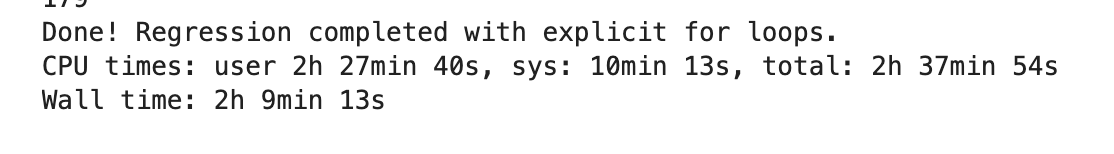

### loops example - don't run 

In [104]:
'''
%%time

# Example data: 2D lat/lon × 1D time
# Assume data_no3_present and data_tauuo_present are xarray DataArrays
# with dimensions ('time', 'lat', 'lon')

lat = data_no3_present.lat
lon = data_no3_present.lon
ntime = data_no3_present.time.size
nlat = lat.size
nlon = lon.size

# Prepare empty arrays for results
slope_loop = np.full((nlat, nlon), np.nan)
r_loop     = np.full((nlat, nlon), np.nan)
p_loop     = np.full((nlat, nlon), np.nan)

# Loop over latitude and longitude
for i in range(nlat):
    print(i)
    for j in range(nlon):
        x = data_no3_present[:, i, j].values
        y = data_tauuo_present[:, i, j].values
        
        # Mask NaNs / invalid points
        mask = np.isfinite(x) & np.isfinite(y)
        
        if mask.sum() >= 3:  # Require at least 3 valid points
            res = linregress(x[mask], y[mask])
            slope_loop[i, j] = res.slope
            r_loop[i, j]     = res.rvalue
            p_loop[i, j]     = res.pvalue

# Convert back to xarray for convenience
slope_loop = xr.DataArray(slope_loop, coords=[lat, lon], dims=['lat', 'lon'])
r_loop     = xr.DataArray(r_loop, coords=[lat, lon], dims=['lat', 'lon'])
p_loop     = xr.DataArray(p_loop, coords=[lat, lon], dims=['lat', 'lon'])

print("Done! Regression completed with explicit for loops.")
'''

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
71
72
73
74
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
Done! Regression completed with explicit for loops.
CPU times: user 2h 27min 40s, sys: 10min 13s, total: 2h 37min 54s
Wall time: 2h 9min 13s


### Plotting Temporal Corrolation 

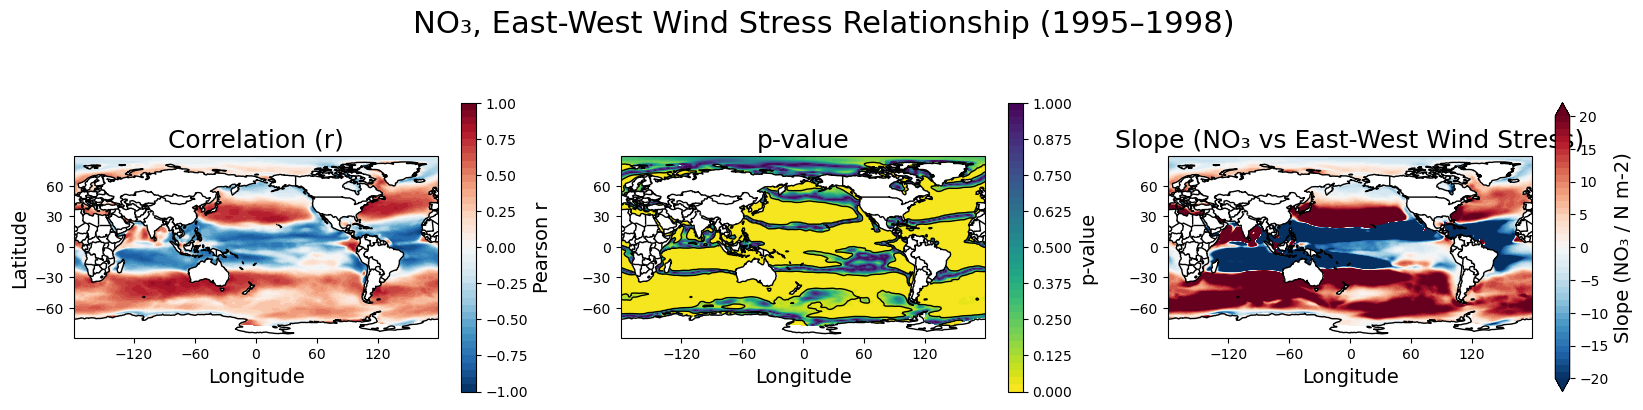

In [118]:
## Create the subplot structure 
fig, axs = plt.subplots(
    nrows=1, # 1 row 
    ncols=3, # 3 columns 
    figsize=(20, 5), # figure size 
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}) # specify map projection 


Lon = slope.lon # create lat by pulling lat data from slope data 
Lat = slope.lat # create lon by pulling lon data from slope data 

#### set up features of every suplot
for ax in axs: # loop through every subplot, given by ax. axs is the array of subplots 
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())

########## We will explicitly write out our suplots here, as you saw last week (timeseries code) you can also do this as a loop#### 


## map corrlation values## - suplot one ; axs[0]
axs[0].set_title("Correlation (r)", fontsize=18) ## call subplot 1 axs[0], set title 
axs[0].set_xlabel("Longitude", fontsize=14) #set x axis 
levels_r = np.linspace(-1, 1, 41) # set levels for colorbar, r will only every be between -1, to 1, by definition
cf_r = axs[0].contourf( Lon - 180, Lat, r, levels=levels_r, cmap="RdBu_r") # create the contour for r, specify lat, lon, levels, and colormap you want to use 

cbar_r = plt.colorbar(cf_r, ax=axs[0], shrink=0.75) # create color bar for first plot
cbar_r.set_label("Pearson r", fontsize=14) # label colorbar 


    
### map p value### - subplot 2 ; axs[1]
axs[1].set_title("p-value", fontsize=18) ## call subplot 2 axs[1], set title
axs[1].set_xlabel("Longitude", fontsize=14) #set x axis 

levels_p = np.linspace(0, 1, 41) # set levels for colorbar, p will only every be between 0, to 1, by definition

cf_p = axs[1].contourf(Lon - 180, Lat, p, levels=levels_p, cmap="viridis_r", extend="neither" ) # create the contour for p, specify lat, lon, levels, and colormap you want to use 
cbar_p = plt.colorbar(cf_p, ax=axs[1], shrink=0.75) # create color bar for second plot
cbar_p.set_label("p-value", fontsize=14) # label colorbar 

axs[1].contour( Lon - 180, Lat, p, levels=[0.05], colors="black", linewidths=1)


#### map slopes##### - subplot 3 ; axs[2]
axs[2].set_title("Slope (NO₃ vs East-West Wind Stress)", fontsize=18) ## call subplot 3 axs[2], set title
axs[2].set_xlabel("Longitude", fontsize=14)#set x axis 

levels_s = np.linspace(-20, 20, 41) # set levels for colorbar, you will have to play with this to get a good colorbar each time 

cf_s = axs[2].contourf( Lon - 180, Lat, slope, levels=levels_s, cmap="RdBu_r", extend="both")  # create the contour for slope, specify lat, lon, levels, and colormap you want to use 

cbar_s = plt.colorbar(cf_s, ax=axs[2], shrink=0.75) ## create color bar for third plot
cbar_s.set_label("Slope (NO₃ / N m-2)", fontsize=14)# label colorbar




axs[0].set_ylabel("Latitude", fontsize=14) # label y axis (only did this on the first subplot for readability) 

plt.suptitle( "NO₃, East-West Wind Stress Relationship (1995–1998)", fontsize=22, y=.97) #add overall title to the plot
    
#plt.tight_layout()
plt.show()

## Mask Your Results to only show significant Correlation 

**What is Masking**: Masking means we will obscuring values from view if they are not relevant to our analysis (in this case, not statistically significant enough). In essence, we want to match up our array of p-values to our array of (in this case) r-values. For each point in space (what I often call a pixel), if the p-value is too high, we will replace the actual value with a NaN so that it prints out blank on the map. - *adapted from Jake Stanger 2024* 

**Create our masks**

In [119]:
r_masked = r.where(p < 0.05) # this will replace the r value with NaN anywhere the p value is NOT under 0.05
slope_masked = slope.where(p < 0.05) # this will replace the slope value with NaN anywhere the p value is NOT under 0.05

**Plot our results**

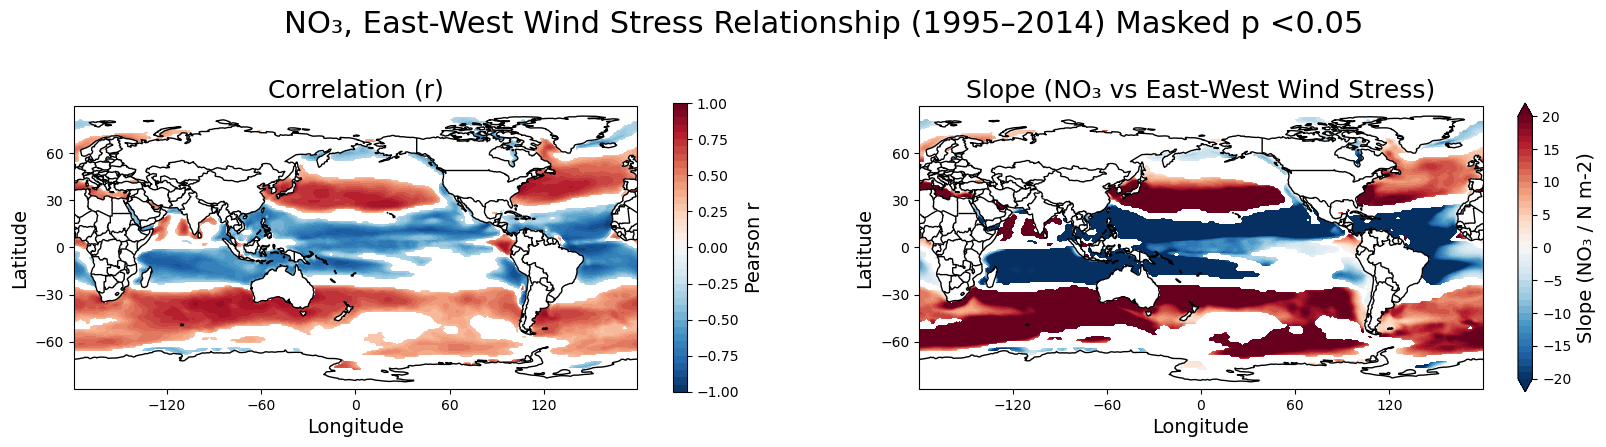

In [120]:
## Create the subplot structure 
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(20, 5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})


Lon = slope.lon
Lat = slope.lat

#### set up features of every suplot
for ax in axs: # loop through every subplot, given by ax. axs is the array of subplots 
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())

########## We will explicitly write out our suplots here, as you saw last week (timeseries code) you can also do this as a loop#### 


## map masked corrlation values## - suplot one ; axs[0]
axs[0].set_title("Correlation (r)", fontsize=18) ## call subplot 1 axs[0], set title
axs[0].set_xlabel("Longitude", fontsize=14) #set x label
levels_r = np.linspace(-1, 1, 41) # set levels for colorbar, r will only every be between -1, to 1, by definition
cf_r = axs[0].contourf( Lon - 180, Lat, r_masked, levels=levels_r, cmap="RdBu_r") ## create the contour for r, specify lat, lon, levels, and colormap you want to use 

cbar_r = plt.colorbar(cf_r, ax=axs[0], shrink=0.75) ## create color bar for first plot
cbar_r.set_label("Pearson r", fontsize=14) # label colorbar



#### map slopes##### - subplot 2 ; axs[1]
axs[1].set_title("Slope (NO₃ vs East-West Wind Stress)", fontsize=18) ## call subplot 2 axs[1], set title
axs[1].set_xlabel("Longitude", fontsize=14) #set x label

levels_s = np.linspace(-20, 20, 41) # set levels for colorbar, you will have to play with this to get a good colorbar each time 

cf_s = axs[1].contourf( Lon - 180, Lat, slope_masked, levels=levels_s, cmap="RdBu_r", extend="both") # create the contour for slope, specify lat, lon, levels, and colormap you want to use 

cbar_s = plt.colorbar(cf_s, ax=axs[1], shrink=0.75) ## create color bar for second plot
cbar_s.set_label("Slope (NO₃ / N m-2)", fontsize=14) # label color bar 




axs[0].set_ylabel("Latitude", fontsize=14) # add y label to subplot 1
axs[1].set_ylabel("Latitude", fontsize=14) # add y label to subplot 2 

plt.suptitle( "NO₃, East-West Wind Stress Relationship (1995–2014) Masked p <0.05", fontsize=22, y=.97) #add overall title to the plot
    
#plt.tight_layout()
plt.show()